In [3]:
from regions import Regions
from regions import CircleSkyRegion, EllipseSkyRegion, RectangleSkyRegion
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy import constants as const

reg_HII = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/resolved_HII_regions.reg')


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
f187182_filedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/filter_subtractions/f187n_minus_f182m.fits'
f405410_filedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/filter_subtractions/f405n_minus_f410m.fits'
f187182_img = fits.getdata(f187182_filedir, ext=('SCI', 1))
f405410_img = fits.getdata(f405410_filedir, ext=('SCI', 1))
f187182_hdr = fits.getheader(f187182_filedir, ext=('SCI', 1))
f405410_hdr = fits.getheader(f405410_filedir, ext=('SCI', 1))
f187182_wcs = WCS(f187182_hdr)
f405410_wcs = WCS(f405410_hdr)



ext = CT06_MWLoc()

keys = ['density_from_paa', 'density_from_bra', 'Q_from_density_paa', 'Q_from_density_bra', 'av_estimate', 'flux_405410', 'flux_187182', 'dered_flux_405410', 'dered_flux_187182',
'EM_from_IPaa', 'EM_from_IBra', 'I_paa', 'I_bra', 'reg_radius_au']
params = {}

reg_bkg_187182= Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/resolved_HII_regions_bkg_187182.reg')
reg_bkg_405410= Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/resolved_HII_regions_bkg_405410.reg')

# get the avg flux density of the background regions
bkg_means_187182 = []
for reg in reg_bkg_187182:
    
    reg = RectangleSkyRegion(center=reg.center, width=reg.width/2, height=reg.height/2, meta=reg.meta)
    reg_pix_187182 = reg.to_pixel(f187182_wcs)
    mask_pix_187182 = reg_pix_187182.to_mask(mode='center',)
    cutout_187182 = mask_pix_187182.cutout(f187182_img)
    mean_187182 = (np.nanmean(cutout_187182.data) * u.MJy/u.sr * f187182_wcs.proj_plane_pixel_area()).to(u.Jy)
    bkg_means_187182.append(mean_187182)

bkg_mean_187182 = np.nanmean(u.Quantity(bkg_means_187182))
if np.isnan(bkg_mean_187182):
    raise ValueError("Background mean for f187182 is NaN. Check the background regions and the image data.")

bkg_means_405410 = []
for reg in reg_bkg_405410:

    reg = RectangleSkyRegion(center=reg.center, width=reg.width/2, height=reg.height/2, meta=reg.meta)
    reg_pix_405410 = reg.to_pixel(f405410_wcs)
    mask_pix_405410 = reg_pix_405410.to_mask(mode='center',)
    cutout_405410 = mask_pix_405410.cutout(f405410_img.data)
    mean_405410 = (np.nanmean(cutout_405410.data) * u.MJy/u.sr * f405410_wcs.proj_plane_pixel_area()).to(u.Jy)
    bkg_means_405410.append(mean_405410)


bkg_mean_405410 = np.nanmean(u.Quantity(bkg_means_405410))
if np.isnan(bkg_mean_405410):
    raise ValueError("Background mean for f405410 is NaN. Check the background regions and the image data.")

from astropy.modeling import models

keys = ['density_from_paa', 'density_from_bra', 'Q_from_density_paa', 'Q_from_density_bra', 'av_estimate', 'flux_405410', 'flux_187182', 'dered_flux_405410', 'dered_flux_187182',
'EM_from_IPaa', 'EM_from_IBra', 'I_paa', 'I_bra', 'reg_radius_au']
params = {}
for reg in reg_HII:
    

    # if ellipseskyregion, then change it to circleskyregion with radius = semi-major axis
   
    reg = CircleSkyRegion(center=reg.center, radius=reg.width/2, meta=reg.meta)
    reg_pix_405 = reg.to_pixel(f405410_wcs)
    reg_pix_187 = reg.to_pixel(f187182_wcs)
    mask_pix_405 = reg_pix_405.to_mask(mode='center',)
    mask_pix_187 = reg_pix_187.to_mask(mode='center',)

    cutout_405410 = mask_pix_405.cutout(f405410_img)
    cutout_187182 = mask_pix_187.cutout(f187182_img)
    mean_405410 = (np.nanmean(cutout_405410.data) * u.MJy/u.sr *
                   wcs_f405n.proj_plane_pixel_area()).to(u.Jy)
    mean_187182 = (np.nanmean(cutout_187182.data) * u.MJy/u.sr *
                   wcs_f187n.proj_plane_pixel_area()).to(u.Jy)
    area_mask_405 = np.pi * reg.radius**2
    area_mask_187 = np.pi * reg.radius**2
    area_mask_pix_405410 = area_mask_405 / wcs_f405n.proj_plane_pixel_area()
    area_mask_pix_187182 = area_mask_187 / wcs_f187n.proj_plane_pixel_area()
    flux_405410 = mean_405410 * area_mask_pix_405410
    flux_187182 = mean_187182 * area_mask_pix_187182

    idx_positive = np.where((flux_405410.value > 0) & (flux_187182.value > 0))

    flux_ratio = flux_405410 / flux_187182

    Adiff = 2.5*np.log10(3.9/flux_ratio.value[idx_positive]) # intrinsic ratio of 3.9 is from the ratio of the emissivities of the two lines at 10^4 K, n_e=10^4 cm^-3, case B recombination (Storey & Hummer 1995)
    av_estimate = Adiff / (ext(1/1.87) - ext(1/4.05))
    print('Adiff:', Adiff, 'flux_ratio:', flux_ratio, 'av_estimate:', av_estimate)

    #print('A_V estimate for region {}: {:.2f}'.format(reg.meta['text'], av_estimate))
    dered_flux_405410 = flux_405410[idx_positive] * 10**(0.4 * av_estimate * ext(1/4.05))
    dered_flux_187182 = flux_187182[idx_positive] * 10**(0.4 * av_estimate * ext(1/1.87))
    print('flux_187182:', flux_187182, 'dered_flux_187182:', dered_flux_187182, 'flux_405410:', flux_405410, 'dered_flux_405410:', dered_flux_405410)

    fig = plt.figure(figsize=(20,20))
    ax1 = fig.add_subplot(2, 2, 1)
    ax2 = fig.add_subplot(2, 2, 2)
    ax3 = fig.add_subplot(2, 2, 3)
    ax4 = fig.add_subplot(2, 2, 4)
    ax1.imshow(flux_405410.value[idx_positive], origin='lower', cmap='inferno', vmin=0, vmax=np.nanpercentile(flux_405410.value, 99))
    cax1 = inset_axes(ax1, width="5%", height="100%", loc='lower left', borderpad=0.1)
    cbar1 = plt.colorbar(ax1.images[0], cax=cax1)
    cbar1.set_label('Flux (Jy)', fontsize=12)
    ax1.set_title('Flux in f405n-f410m', fontsize=14)
    ax2.imshow(flux_187182.value[idx_positive], origin='lower', cmap='inferno', vmin=0, vmax=np.nanpercentile(flux_187182.value, 99))
    cax2 = inset_axes(ax2, width="5%", height="100%", loc='lower left', borderpad=0.1)
    cbar2 = plt.colorbar(ax2.images[0], cax=cax2)
    cbar2.set_label('Flux (Jy)', fontsize=12)
    ax2.set_title('Flux in f187n-f182m', fontsize=14)

    ax3.imshow(av_estimate.value, origin='lower', cmap='inferno', vmin=0, vmax=np.nanpercentile(av_estimate.value, 99))
    ax3.set_title('A_V estimate', fontsize=14)
    cax3 = inset_axes(ax3, width="5%", height="100%", loc='lower left', borderpad=0.1)
    cbar3 = plt.colorbar(ax3.images[0], cax=cax3)
    cbar3.set_label('A_V', fontsize=12)

    ax4.imshow(dered_flux_405410.value, origin='lower', cmap='inferno', vmin=0, vmax=np.nanpercentile(dered_flux_405410.value, 99))
    ax4.set_title('Dereddened Flux in f405n-f410m', fontsize=14)
    cax4 = inset_axes(ax4, width="5%", height="100%", loc='lower left', borderpad=0.1)
    cbar4 = plt.colorbar(ax4.images[0], cax=cax4)
    cbar4.set_label('Flux (Jy)', fontsize=12)

    tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
    wave_paa = tab_paa['Wavelength'] 
    trans_paa = tab_paa['Transmission']
    # get the frequency width of PaA from svo_fps
    delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
    print('delta_lam:', delta_lam)
    delta_nu_paa = (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
    reg_radius_au = (reg.radius.value * 5400)*u.au
    I_paa = (dered_flux_187182 * delta_nu_paa / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr)
    nu_paa = (const.c/(1.87e-6*u.m)).to(u.GHz)
    bb = models.BlackBody(temperature=1e4*u.K)
    EM_from_IPaa_roberto = (12.143*np.log(1/(1-I_paa/bb(nu_paa)/delta_nu_paa))*(nu_paa.to(u.GHz).value)**2.1 *(1e4)**1.35*u.pc*u.cm**(-6) ).to(u.pc*u.cm**(-6))
    density_from_paa = ((EM_from_IPaa_roberto / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_paa:', density_from_paa)
    Q_from_density_paa = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_paa:', Q_from_density_paa)


    tab_bra = SvoFps.get_transmission_data(f'JWST/NIRCAM.f405n')
    wave_bra = tab_bra['Wavelength']
    trans_bra = tab_bra['Transmission']
    # get the frequency width of BrA from svo_fps
    delta_lam_bra = np.trapezoid(trans_bra / trans_bra.max(), wave_bra) * u.AA
    print('delta_lam_bra:', delta_lam_bra)
    delta_nu_bra = (const.c/4.05e-6/u.m**2 * delta_lam_bra).to(u.Hz)
    I_bra = (dered_flux_405410  * delta_nu_bra / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr)
    nu_bra = (const.c/(4.05e-6*u.m)).to(u.GHz   )
    EM_from_IBra_roberto = (12.143*np.log(1/(1-I_bra/bb(nu_bra)/delta_nu_bra))*(nu_bra.to(u.GHz).value)**2.1 *(1e4)**1.35 *u.pc*u.cm**(-6) ).to(u.pc*u.cm**(-6))
    density_from_bra = ((EM_from_IBra_roberto / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_bra:', density_from_bra)
    Q_from_density_bra = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_bra:', Q_from_density_bra)


    


    inputs = [density_from_paa, density_from_bra, Q_from_density_paa, Q_from_density_bra, av_estimate, flux_405410, flux_187182, dered_flux_405410, dered_flux_187182,
    EM_from_IPaa_roberto, EM_from_IBra_roberto, I_paa, I_bra, reg_radius_au]
    for key, value in zip(keys, inputs):
        if key not in params:
            params[key] = []
        if isinstance(value, u.Quantity):
            params[key].append(value.value)
        else:
            params[key].append(value)
    

    








Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


NameError: name 'wcs_f405n' is not defined

[np.float64(0.4023304017919342), np.float64(1.1549063772104338), np.float64(0.7490023535121861), np.float64(0.1100418493176712), np.float64(0.14346249382268011), np.float64(0.1903616818069845), np.float64(0.2226747467764724), np.float64(0.5902550754231224), np.float64(0.06645534409081444)]


Text(0, 0.5, 'Number of HII regions')

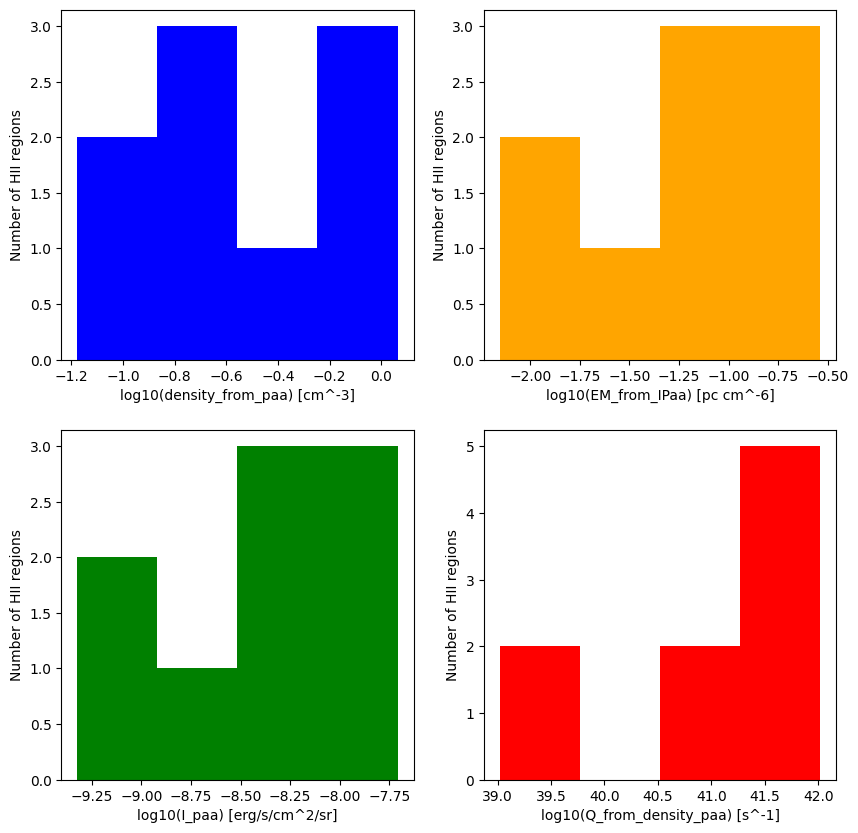

In [2]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
print(params['density_from_paa'])
ax1.hist(np.log10(params['density_from_paa']), bins=np.linspace(np.nanmin(np.log10(params['density_from_paa'])), np.nanmax(np.log10(params['density_from_paa'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_paa) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IPaa']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IPaa'])), np.nanmax(np.log10(params['EM_from_IPaa'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IPaa) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_paa']), bins=np.linspace(np.nanmin(np.log10(params['I_paa'])), np.nanmax(np.log10(params['I_paa'])), 5), color='green')
ax3.set_xlabel('log10(I_paa) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_paa'], bins=np.linspace(np.nanmin(params['Q_from_density_paa']), np.nanmax(params['Q_from_density_paa']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_paa) [s^-1]')
ax4.set_ylabel('Number of HII regions')

Text(0, 0.5, 'Number of HII regions')

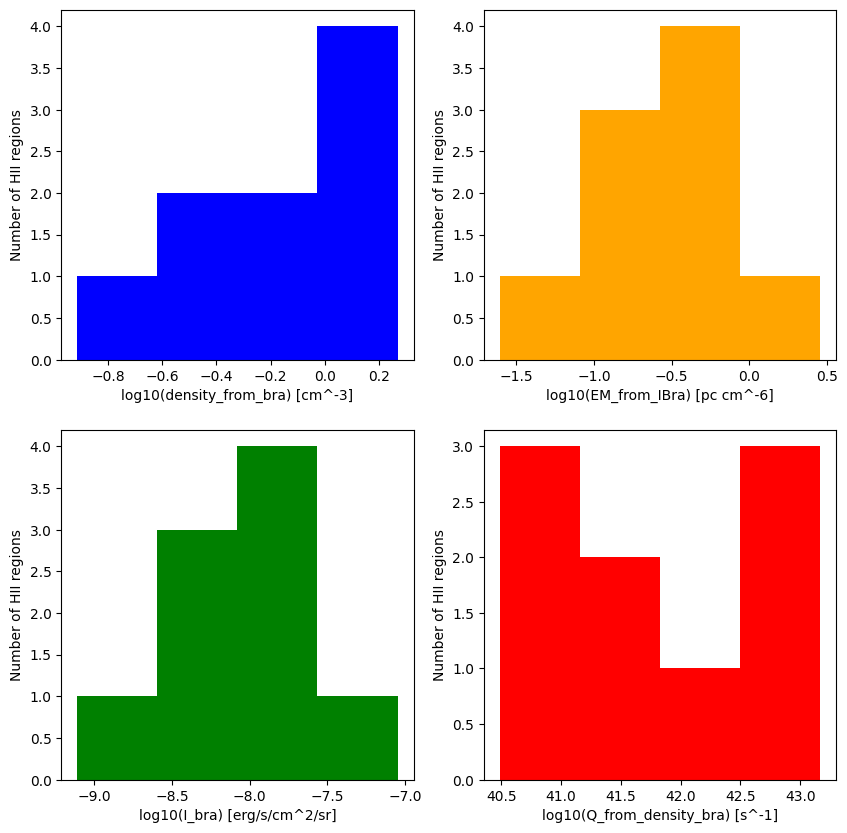

In [3]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
ax1.hist(np.log10(params['density_from_bra']), bins=np.linspace(np.nanmin(np.log10(params['density_from_bra'])), np.nanmax(np.log10(params['density_from_bra'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_bra) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IBra']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IBra'])), np.nanmax(np.log10(params['EM_from_IBra'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IBra) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_bra']), bins=np.linspace(np.nanmin(np.log10(params['I_bra'])), np.nanmax(np.log10(params['I_bra'])), 5), color='green')
ax3.set_xlabel('log10(I_bra) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_bra'], bins=np.linspace(np.nanmin(params['Q_from_density_bra']), np.nanmax(params['Q_from_density_bra']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_bra) [s^-1]')
ax4.set_ylabel('Number of HII regions')

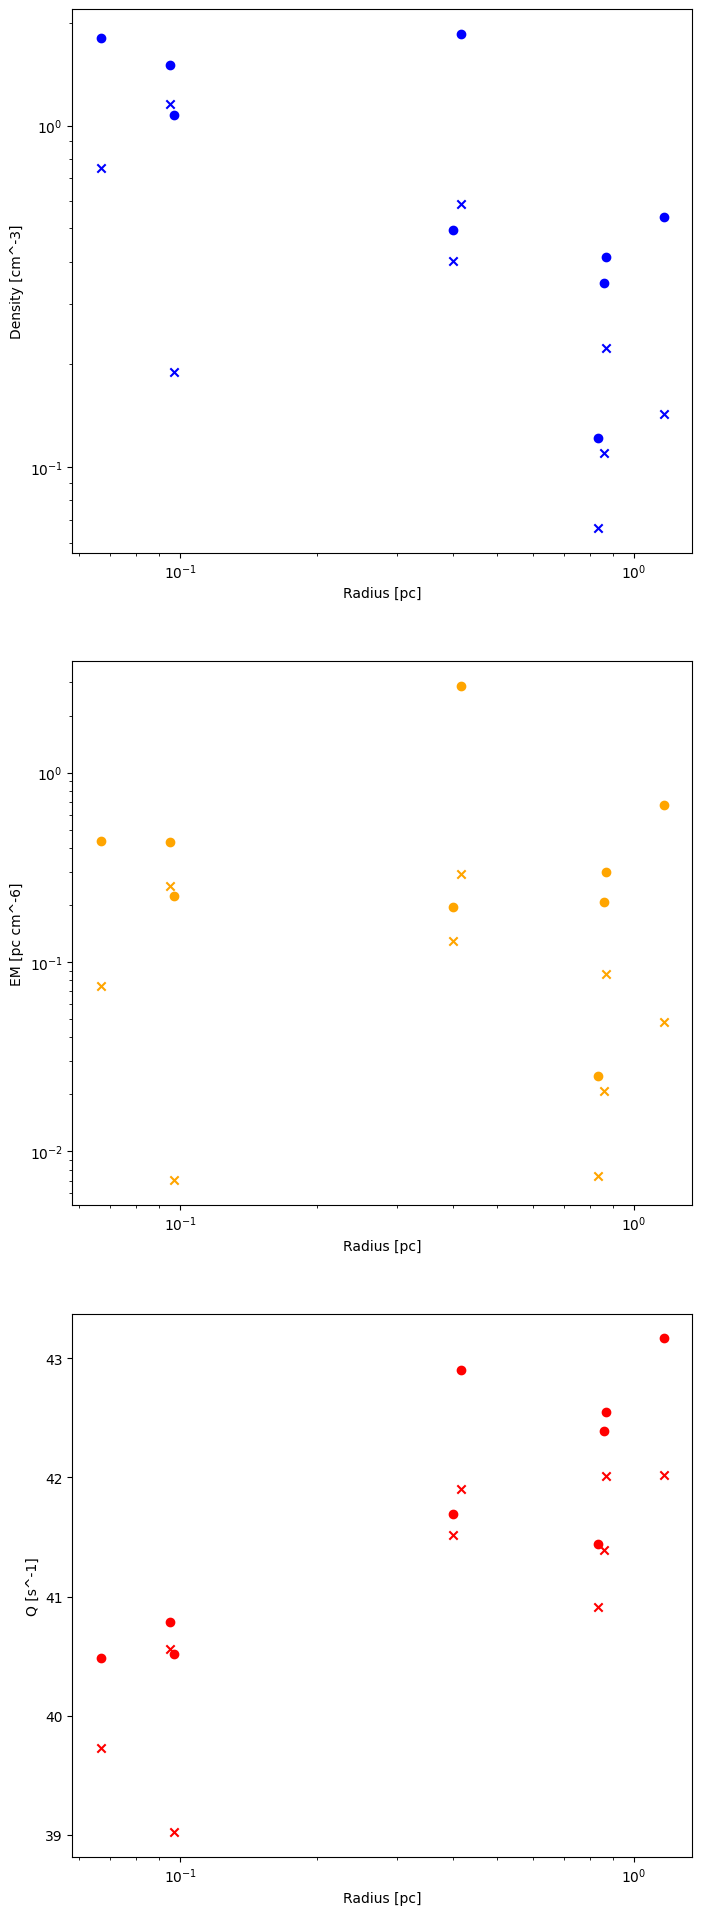

In [4]:
fig = plt.figure(figsize=(8, 24))
ax1 = fig.add_subplot(311)
ax1.scatter((params['reg_radius_au']*u.au).to(u.pc), params['density_from_bra'], color='blue')
ax1.scatter((params['reg_radius_au']*u.au).to(u.pc), params['density_from_paa'], color='blue',marker='x')
ax1.set_xlabel('Radius [pc]')
ax1.set_ylabel('Density [cm^-3]')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax2 = fig.add_subplot(312)
ax2.scatter((params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IBra'], color='orange')
ax2.scatter((params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IPaa'], color='orange',marker='x')
ax2.set_xlabel('Radius [pc]')
ax2.set_ylabel('EM [pc cm^-6]')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax3 = fig.add_subplot(313)
ax3.scatter((params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_bra'], color='red')
ax3.scatter((params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_paa'], color='red',marker='x')
ax3.set_xlabel('Radius [pc]')
ax3.set_ylabel('Q [s^-1]')
ax3.set_xscale('log')
#ax3.set_yscale('log')

In [4]:

from astropy.modeling import models

keys = ['density_from_paa', 'density_from_bra', 'Q_from_density_paa', 'Q_from_density_bra', 'av_estimate', 'flux_405410', 'flux_187182', 'dered_flux_405410', 'dered_flux_187182',
'EM_from_IPaa', 'EM_from_IBra', 'I_paa', 'I_bra', 'reg_radius_au']
params = {}
for reg in reg_HII:
    

    # if ellipseskyregion, then change it to circleskyregion with radius = semi-major axis
    if isinstance(reg, EllipseSkyRegion):
        reg = CircleSkyRegion(center=reg.center, radius=reg.width/2, meta=reg.meta)
    reg_pix_405 = reg.to_pixel(wcs_f405n)
    reg_pix_187 = reg.to_pixel(wcs_f187n)
    mask_pix_405 = reg_pix_405.to_mask(mode='center',)
    mask_pix_187 = reg_pix_187.to_mask(mode='center',)

    cutout_405410 = mask_pix_405.cutout(img_for_405410.data)
    cutout_187182 = mask_pix_187.cutout(img_for_187182.data)
    mean_405410 = (np.nanmean(cutout_405410.data) * u.MJy/u.sr *
                   wcs_f405n.proj_plane_pixel_area()).to(u.Jy)
    mean_187182 = (np.nanmean(cutout_187182.data) * u.MJy/u.sr *
                   wcs_f187n.proj_plane_pixel_area()).to(u.Jy)
    area_mask_405 = np.pi * reg.radius**2
    area_mask_187 = np.pi * reg.radius**2
    area_mask_pix_405410 = area_mask_405 / wcs_f405n.proj_plane_pixel_area()
    area_mask_pix_187182 = area_mask_187 / wcs_f187n.proj_plane_pixel_area()
    flux_405410 = mean_405410 * area_mask_pix_405410
    flux_187182 = mean_187182 * area_mask_pix_187182

    flux_ratio = flux_405410 / flux_187182

    Adiff = 2.5*np.log10(3.9/flux_ratio.value) # intrinsic ratio of 3.9 is from the ratio of the emissivities of the two lines at 10^4 K, n_e=10^4 cm^-3, case B recombination (Storey & Hummer 1995)
    av_estimate = Adiff / (ext(1/1.87) - ext(1/4.05))

    #print('A_V estimate for region {}: {:.2f}'.format(reg.meta['text'], av_estimate))
    dered_flux_405410 = flux_405410 * 10**(0.4 * av_estimate * ext(1/4.05))
    dered_flux_187182 = flux_187182 * 10**(0.4 * av_estimate * ext(1/1.87))
    print('flux_187182:', flux_187182, 'dered_flux_187182:', dered_flux_187182, 'flux_405410:', flux_405410, 'dered_flux_405410:', dered_flux_405410)

    tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
    wave_paa = tab_paa['Wavelength'] 
    trans_paa = tab_paa['Transmission']
    # get the frequency width of PaA from svo_fps
    delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
    print('delta_lam:', delta_lam)
    delta_nu_paa = (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
    reg_radius_au = (reg.radius.value * 5400)*u.au
    I_paa = (dered_flux_187182 * delta_nu_paa / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr)
    nu_paa = (const.c/(1.87e-6*u.m)).to(u.GHz)
    bb = models.BlackBody(temperature=1e4*u.K)
    EM_from_IPaa_roberto = (12.143*np.log(1/(1-I_paa/bb(nu_paa)/delta_nu_paa))*(nu_paa.to(u.GHz).value)**2.1 *(1e4)**1.35*u.pc*u.cm**(-6) ).to(u.pc*u.cm**(-6))
    density_from_paa = ((EM_from_IPaa_roberto / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_paa:', density_from_paa)
    Q_from_density_paa = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_paa:', Q_from_density_paa)


    tab_bra = SvoFps.get_transmission_data(f'JWST/NIRCAM.f405n')
    wave_bra = tab_bra['Wavelength']
    trans_bra = tab_bra['Transmission']
    # get the frequency width of BrA from svo_fps
    delta_lam_bra = np.trapezoid(trans_bra / trans_bra.max(), wave_bra) * u.AA
    print('delta_lam_bra:', delta_lam_bra)
    delta_nu_bra = (const.c/4.05e-6/u.m**2 * delta_lam_bra).to(u.Hz)
    I_bra = (dered_flux_405410  * delta_nu_bra / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr)
    nu_bra = (const.c/(4.05e-6*u.m)).to(u.GHz   )
    EM_from_IBra_roberto = (12.143*np.log(1/(1-I_bra/bb(nu_bra)/delta_nu_bra))*(nu_bra.to(u.GHz).value)**2.1 *(1e4)**1.35 *u.pc*u.cm**(-6) ).to(u.pc*u.cm**(-6))
    density_from_bra = ((EM_from_IBra_roberto / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_bra:', density_from_bra)
    Q_from_density_bra = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_bra:', Q_from_density_bra)


    


    inputs = [density_from_paa, density_from_bra, Q_from_density_paa, Q_from_density_bra, av_estimate, flux_405410, flux_187182, dered_flux_405410, dered_flux_187182,
    EM_from_IPaa_roberto, EM_from_IBra_roberto, I_paa, I_bra, reg_radius_au]
    for key, value in zip(keys, inputs):
        if key not in params:
            params[key] = []
        if isinstance(value, u.Quantity):
            params[key].append(value.value)
        else:
            params[key].append(value)
    
    

NameError: name 'wcs_f405n' is not defined

[np.float64(4168.393175439592), np.float64(11291.139650922347), np.float64(7597.695977358539), np.float64(1210.6882633666607), np.float64(1414.9901005130173), np.float64(2179.6457307811165), np.float64(2262.714347545119), np.float64(5554.2733180441965), np.float64(1313.8775121599497)]


Text(0, 0.5, 'Number of HII regions')

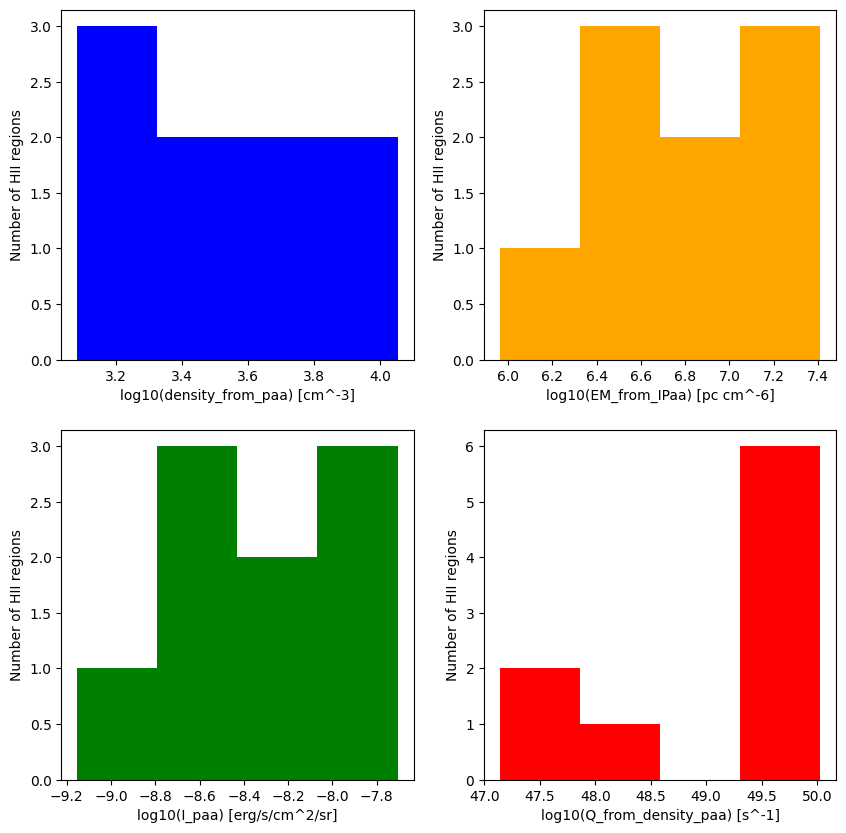

In [ ]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
print(params['density_from_paa'])
ax1.hist(np.log10(params['density_from_paa']), bins=np.linspace(np.nanmin(np.log10(params['density_from_paa'])), np.nanmax(np.log10(params['density_from_paa'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_paa) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IPaa']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IPaa'])), np.nanmax(np.log10(params['EM_from_IPaa'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IPaa) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_paa']), bins=np.linspace(np.nanmin(np.log10(params['I_paa'])), np.nanmax(np.log10(params['I_paa'])), 5), color='green')
ax3.set_xlabel('log10(I_paa) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_paa'], bins=np.linspace(np.nanmin(params['Q_from_density_paa']), np.nanmax(params['Q_from_density_paa']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_paa) [s^-1]')
ax4.set_ylabel('Number of HII regions')

Text(0, 0.5, 'Number of HII regions')

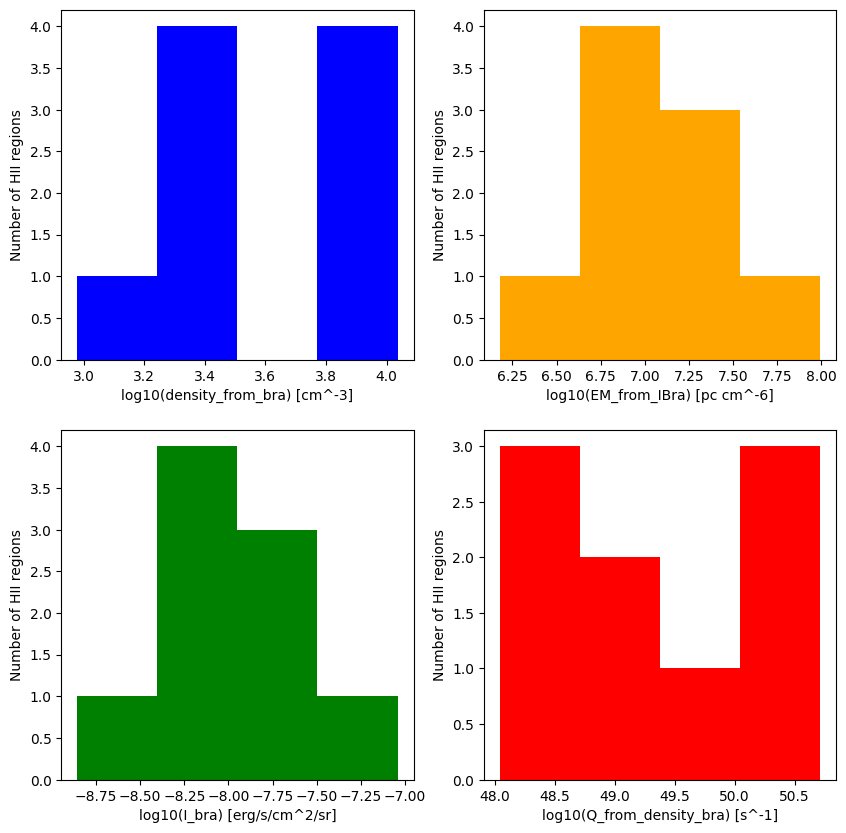

In [ ]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
ax1.hist(np.log10(params['density_from_bra']), bins=np.linspace(np.nanmin(np.log10(params['density_from_bra'])), np.nanmax(np.log10(params['density_from_bra'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_bra) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IBra']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IBra'])), np.nanmax(np.log10(params['EM_from_IBra'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IBra) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_bra']), bins=np.linspace(np.nanmin(np.log10(params['I_bra'])), np.nanmax(np.log10(params['I_bra'])), 5), color='green')
ax3.set_xlabel('log10(I_bra) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_bra'], bins=np.linspace(np.nanmin(params['Q_from_density_bra']), np.nanmax(params['Q_from_density_bra']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_bra) [s^-1]')
ax4.set_ylabel('Number of HII regions')

(0.01, 2.0)

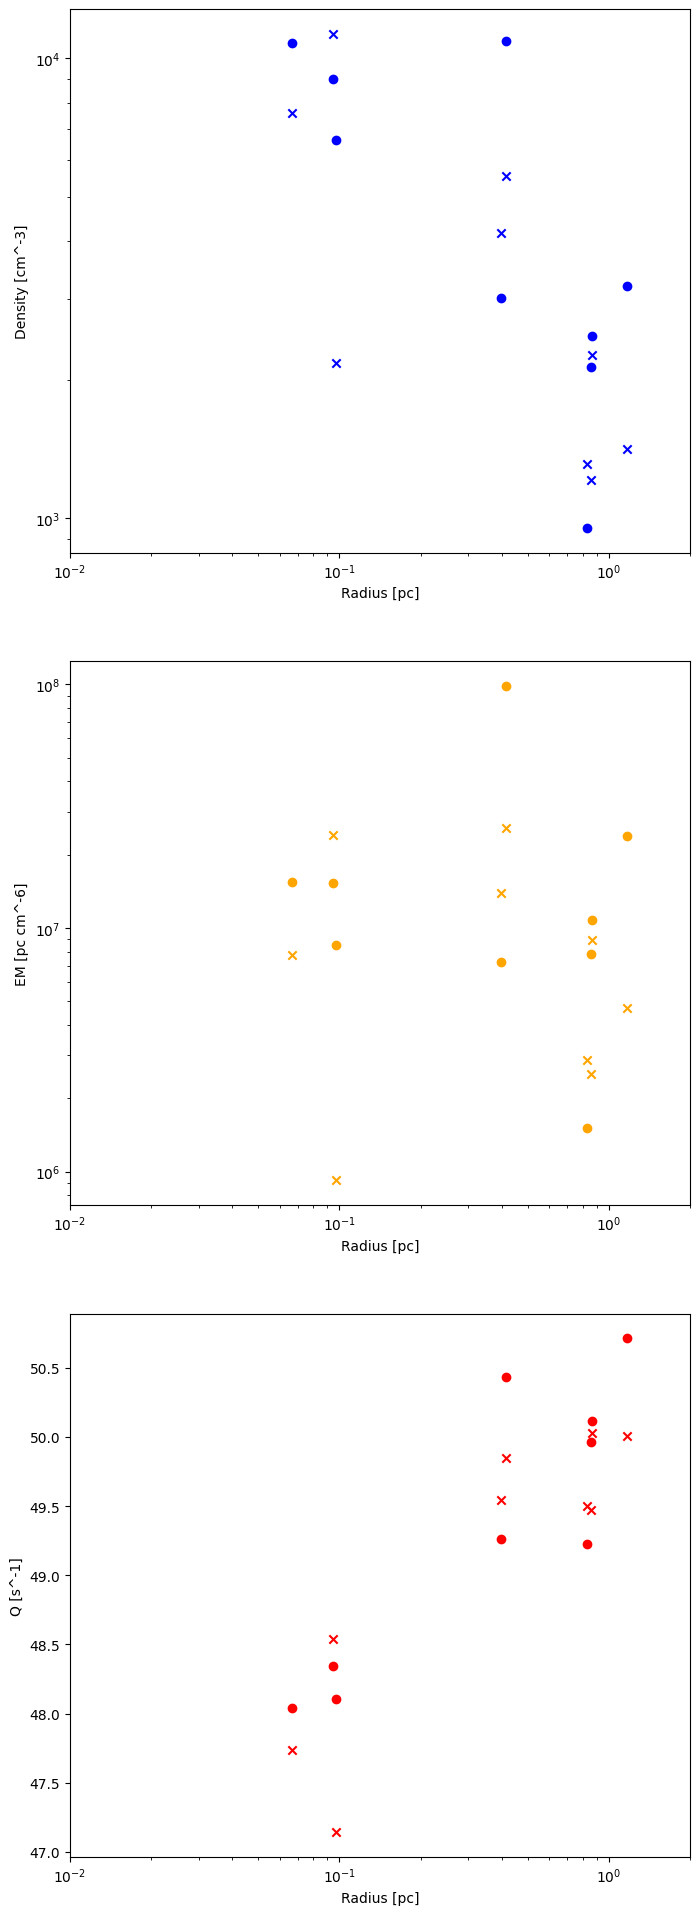

In [ ]:
fig = plt.figure(figsize=(8, 24))
ax1 = fig.add_subplot(311)
ax1.scatter((params['reg_radius_au']*u.au).to(u.pc), params['density_from_bra'], color='blue')
ax1.scatter((params['reg_radius_au']*u.au).to(u.pc), params['density_from_paa'], color='blue',marker='x')
ax1.set_xlabel('Radius [pc]')
ax1.set_ylabel('Density [cm^-3]')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(1e-2, 2e0)
ax2 = fig.add_subplot(312)
ax2.scatter((params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IBra'], color='orange')
ax2.scatter((params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IPaa'], color='orange',marker='x')
ax2.set_xlabel('Radius [pc]')
ax2.set_ylabel('EM [pc cm^-6]')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e-2,2e0)
ax3 = fig.add_subplot(313)
ax3.scatter((params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_bra'], color='red')
ax3.scatter((params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_paa'], color='red',marker='x')
ax3.set_xlabel('Radius [pc]')
ax3.set_ylabel('Q [s^-1]')
ax3.set_xscale('log')
ax3.set_xlim(1e-2,2e0)
#ax3.set_yscale('log')

In [ ]:
# $$S_{\paa}(T_4,EM) = 6.4 \left(\frac{EM}{10^6 \mathrm{~cm}^{-6}  \mathrm{~pc}}\right)\left( T_4^{-0.874-0.058 \ln T_4} \right) \mathrm{MJy~sr}^{-1} $$
# S_paa = 6.4 * (np.array(params['EM_from_IPaa']) / 1e6) * (1**(-0.874 - 0.058 * np.log(1))) * u.MJy/u.sr
# EM from paa = 1 / (6.4 * 1**(-0.874 - 0.058 * np.log(1))) * S_paa / u.MJy * 1e6 * u.cm**-6 * u.pc


from astropy.modeling import models

keys = ['density_from_paa', 'density_from_bra', 'Q_from_density_paa', 'Q_from_density_bra', 'av_estimate', 'flux_405410', 'flux_187182', 'dered_flux_405410', 'dered_flux_187182',
'EM_from_IPaa', 'EM_from_IBra', 'I_paa', 'I_bra', 'reg_radius_au']
params = {}
for reg in reg_HII:
    

    # if ellipseskyregion, then change it to circleskyregion with radius = semi-major axis
    if isinstance(reg, EllipseSkyRegion):
        reg = CircleSkyRegion(center=reg.center, radius=reg.width/2, meta=reg.meta)
    reg_pix_405 = reg.to_pixel(wcs_f405n)
    reg_pix_187 = reg.to_pixel(wcs_f187n)
    mask_pix_405 = reg_pix_405.to_mask(mode='center',)
    mask_pix_187 = reg_pix_187.to_mask(mode='center',)

    cutout_405410 = mask_pix_405.cutout(img_for_405410.data)
    cutout_187182 = mask_pix_187.cutout(img_for_187182.data)
    mean_405410 = (np.nanmean(cutout_405410.data) * u.MJy/u.sr *
                   wcs_f405n.proj_plane_pixel_area()).to(u.Jy)
    mean_187182 = (np.nanmean(cutout_187182.data) * u.MJy/u.sr *
                   wcs_f187n.proj_plane_pixel_area()).to(u.Jy)
    area_mask_405 = np.pi * reg.radius**2
    area_mask_187 = np.pi * reg.radius**2
    area_mask_pix_405410 = area_mask_405 / wcs_f405n.proj_plane_pixel_area()
    area_mask_pix_187182 = area_mask_187 / wcs_f187n.proj_plane_pixel_area()
    flux_405410 = mean_405410 * area_mask_pix_405410
    flux_187182 = mean_187182 * area_mask_pix_187182

    flux_ratio = flux_405410 / flux_187182

    Adiff = 2.5*np.log10(3.9/flux_ratio.value) # intrinsic ratio of 3.9 is from the ratio of the emissivities of the two lines at 10^4 K, n_e=10^4 cm^-3, case B recombination (Storey & Hummer 1995)
    av_estimate = Adiff / (ext(1/1.87) - ext(1/4.05))

    #print('A_V estimate for region {}: {:.2f}'.format(reg.meta['text'], av_estimate))
    dered_flux_405410 = flux_405410 * 10**(0.4 * av_estimate * ext(1/4.05))
    dered_flux_187182 = flux_187182 * 10**(0.4 * av_estimate * ext(1/1.87))
    print('flux_187182:', flux_187182, 'dered_flux_187182:', dered_flux_187182, 'flux_405410:', flux_405410, 'dered_flux_405410:', dered_flux_405410)

    tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
    wave_paa = tab_paa['Wavelength'] 
    trans_paa = tab_paa['Transmission']
    # get the frequency width of PaA from svo_fps
    delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
    print('delta_lam:', delta_lam)
    delta_nu_paa = (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
    reg_radius_au = (reg.radius.value * 5400)*u.au
    I_paa = (dered_flux_187182 * delta_nu_paa / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr) # Jy/sr*Hz
    S_paa = (I_paa / delta_nu_paa).to(u.MJy/u.sr)
    nu_paa = (const.c/(1.87e-6*u.m)).to(u.GHz)
    #bb = models.BlackBody(temperature=1e4*u.K)
    #EM_from_IPaa_roberto = (12.143*np.log(1/(1-I_paa/bb(nu_paa)/delta_nu_paa))*(nu_paa.to(u.GHz).value)**2.1 *(1e4)**1.35*u.pc*u.cm**(-6) ).to(u.pc*u.cm**(-6))
    EM_from_IPaa_roberto = 1/6.4 * 1e6*S_paa.value * u.pc/u.cm**6 
    density_from_paa = ((EM_from_IPaa_roberto / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_paa:', density_from_paa)
    Q_from_density_paa = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_paa:', Q_from_density_paa)


    tab_bra = SvoFps.get_transmission_data(f'JWST/NIRCAM.f405n')
    wave_bra = tab_bra['Wavelength']
    trans_bra = tab_bra['Transmission']
    # get the frequency width of BrA from svo_fps
    delta_lam_bra = np.trapezoid(trans_bra / trans_bra.max(), wave_bra) * u.AA
    print('delta_lam_bra:', delta_lam_bra)
    delta_nu_bra = (const.c/4.05e-6/u.m**2 * delta_lam_bra).to(u.Hz)
    I_bra = (dered_flux_405410  * delta_nu_bra / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr)
    nu_bra = (const.c/(4.05e-6*u.m)).to(u.GHz   )
    S_bra = (I_bra / delta_nu_bra).to(u.MJy/u.sr)
    bb = models.BlackBody(temperature=1e4*u.K)
    #EM_from_IBra_roberto = (12.143*np.log(1/(1-I_bra/bb(nu_bra)/delta_nu_bra))*(nu_bra.to(u.GHz).value)**2.1 *(1e4)**1.35 *u.pc*u.cm**(-6) ).to(u.pc*u.cm**(-6))
    EM_from_IBra_roberto =  1/3.22 * 1e6*S_paa.value * u.pc/u.cm**6 
    density_from_bra = ((EM_from_IBra_roberto / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_bra:', density_from_bra)
    Q_from_density_bra = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_bra:', Q_from_density_bra)


    


    inputs = [density_from_paa, density_from_bra, Q_from_density_paa, Q_from_density_bra, av_estimate, flux_405410, flux_187182, dered_flux_405410, dered_flux_187182,
    EM_from_IPaa_roberto, EM_from_IBra_roberto, I_paa, I_bra, reg_radius_au]
    for key, value in zip(keys, inputs):
        if key not in params:
            params[key] = []
        if isinstance(value, u.Quantity):
            params[key].append(value.value)
        else:
            params[key].append(value)
    
    


x has no units, assuming x units are inverse microns
x has no units, assuming x units are inverse microns
x has no units, assuming x units are inverse microns


flux_187182: 4874375.916555516 arcsec2 Jy / deg2 dered_flux_187182: 19736865.640097108 arcsec2 Jy / deg2 flux_405410: 8094530.8857059805 arcsec2 Jy / deg2 dered_flux_405410: 13955934.032443527 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 7401.785147513455 1 / cm3
Q_from_density_paa: 50.04369074215463
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 10435.145904685573 1 / cm3
Q_from_density_bra: 50.34201484444269
flux_187182: 564136.4630273908 arcsec2 Jy / deg2 dered_flux_187182: 1945601.719800619 arcsec2 Jy / deg2 flux_405410: 1033242.1563798964 arcsec2 Jy / deg2 dered_flux_405410: 1673498.1094847363 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 20049.587040262853 1 / cm3
Q_from_density_paa: 49.03746649899788
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 28266.203614964565 1 / cm3
Q_from_density_bra: 49.335790601285936
flux_187182: 229689.59599325113 arcsec2 Jy / deg2 dered_flux_187182: 308652.9927471

x has no units, assuming x units are inverse microns


flux_187182: 17813372.927789014 arcsec2 Jy / deg2 dered_flux_187182: 16765868.57865161 arcsec2 Jy / deg2 flux_405410: 72090685.26529798 arcsec2 Jy / deg2 dered_flux_405410: 70408880.31246088 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 2149.800617954693 1 / cm3
Q_from_density_paa: 49.97283861507827
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 3030.8206287069406 1 / cm3
Q_from_density_bra: 50.27116271736632


x has no units, assuming x units are inverse microns
x has no units, assuming x units are inverse microns
x has no units, assuming x units are inverse microns


flux_187182: 91317106.37933971 arcsec2 Jy / deg2 dered_flux_187182: 57120722.7715615 arcsec2 Jy / deg2 flux_405410: 474253999.78414553 arcsec2 Jy / deg2 dered_flux_405410: 395045218.14152163 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 2512.576329789858 1 / cm3
Q_from_density_paa: 50.50520625161986
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 3542.2671795363513 1 / cm3
Q_from_density_bra: 50.80353035390792
flux_187182: 202073.1751422264 arcsec2 Jy / deg2 dered_flux_187182: 77736.17514896873 arcsec2 Jy / deg2 flux_405410: 1412083.2537487103 arcsec2 Jy / deg2 dered_flux_405410: 973333.8684252297 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 3870.3524880270697 1 / cm3
Q_from_density_paa: 47.639035725754276
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 5456.480039641934 1 / cm3
Q_from_density_bra: 47.93735982804233
flux_187182: 29772645.15774704 arcsec2 Jy / deg2 dered_flux_187182: 60261602.097315565 

x has no units, assuming x units are inverse microns
x has no units, assuming x units are inverse microns


[np.float64(7401.785147513455), np.float64(20049.587040262853), np.float64(13491.172342405529), np.float64(2149.800617954693), np.float64(2512.576329789858), np.float64(3870.3524880270697), np.float64(4017.8863708178287), np.float64(9862.675308528424), np.float64(2333.033877514157)]


Text(0, 0.5, 'Number of HII regions')

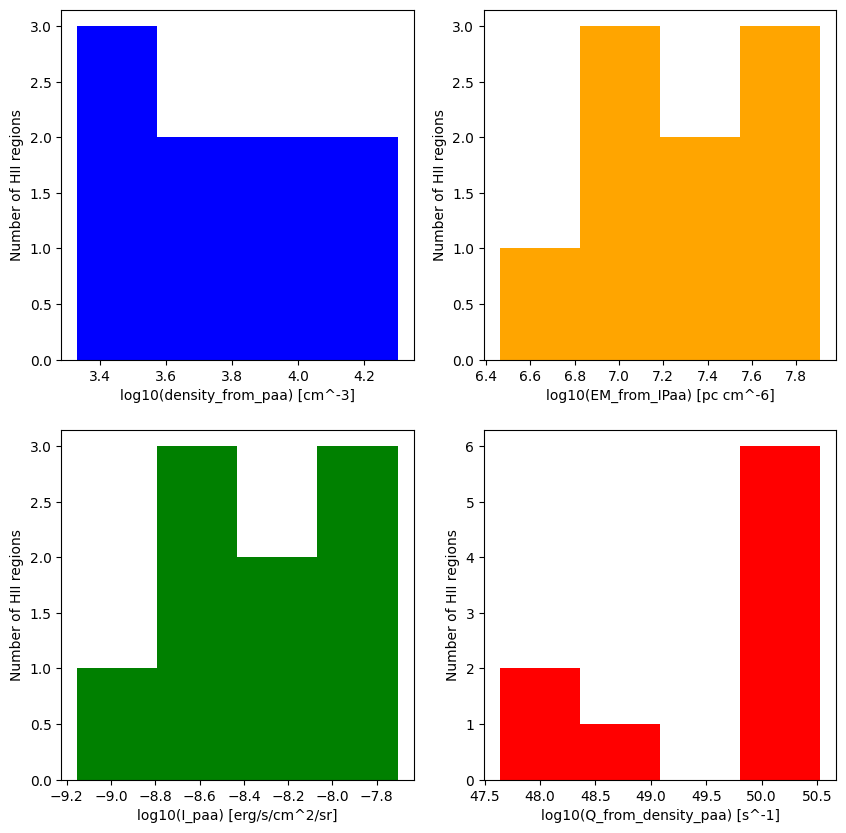

In [ ]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
print(params['density_from_paa'])
ax1.hist(np.log10(params['density_from_paa']), bins=np.linspace(np.nanmin(np.log10(params['density_from_paa'])), np.nanmax(np.log10(params['density_from_paa'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_paa) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IPaa']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IPaa'])), np.nanmax(np.log10(params['EM_from_IPaa'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IPaa) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_paa']), bins=np.linspace(np.nanmin(np.log10(params['I_paa'])), np.nanmax(np.log10(params['I_paa'])), 5), color='green')
ax3.set_xlabel('log10(I_paa) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_paa'], bins=np.linspace(np.nanmin(params['Q_from_density_paa']), np.nanmax(params['Q_from_density_paa']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_paa) [s^-1]')
ax4.set_ylabel('Number of HII regions')

Text(0, 0.5, 'Number of HII regions')

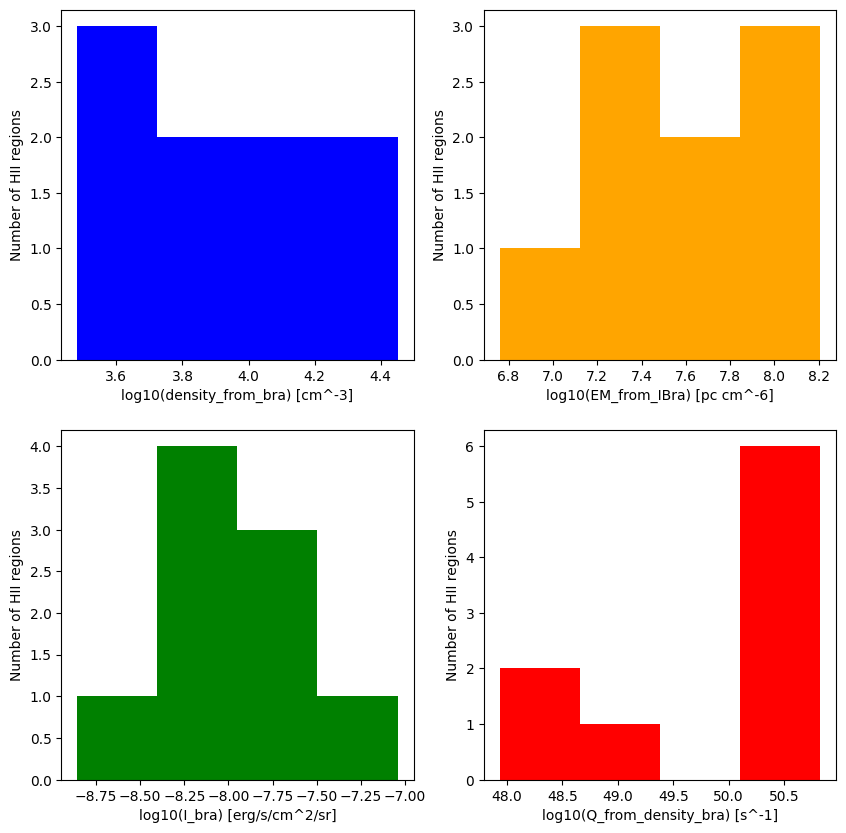

In [ ]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
ax1.hist(np.log10(params['density_from_bra']), bins=np.linspace(np.nanmin(np.log10(params['density_from_bra'])), np.nanmax(np.log10(params['density_from_bra'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_bra) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IBra']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IBra'])), np.nanmax(np.log10(params['EM_from_IBra'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IBra) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_bra']), bins=np.linspace(np.nanmin(np.log10(params['I_bra'])), np.nanmax(np.log10(params['I_bra'])), 5), color='green')
ax3.set_xlabel('log10(I_bra) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_bra'], bins=np.linspace(np.nanmin(params['Q_from_density_bra']), np.nanmax(params['Q_from_density_bra']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_bra) [s^-1]')
ax4.set_ylabel('Number of HII regions')

(0.01, 2.0)

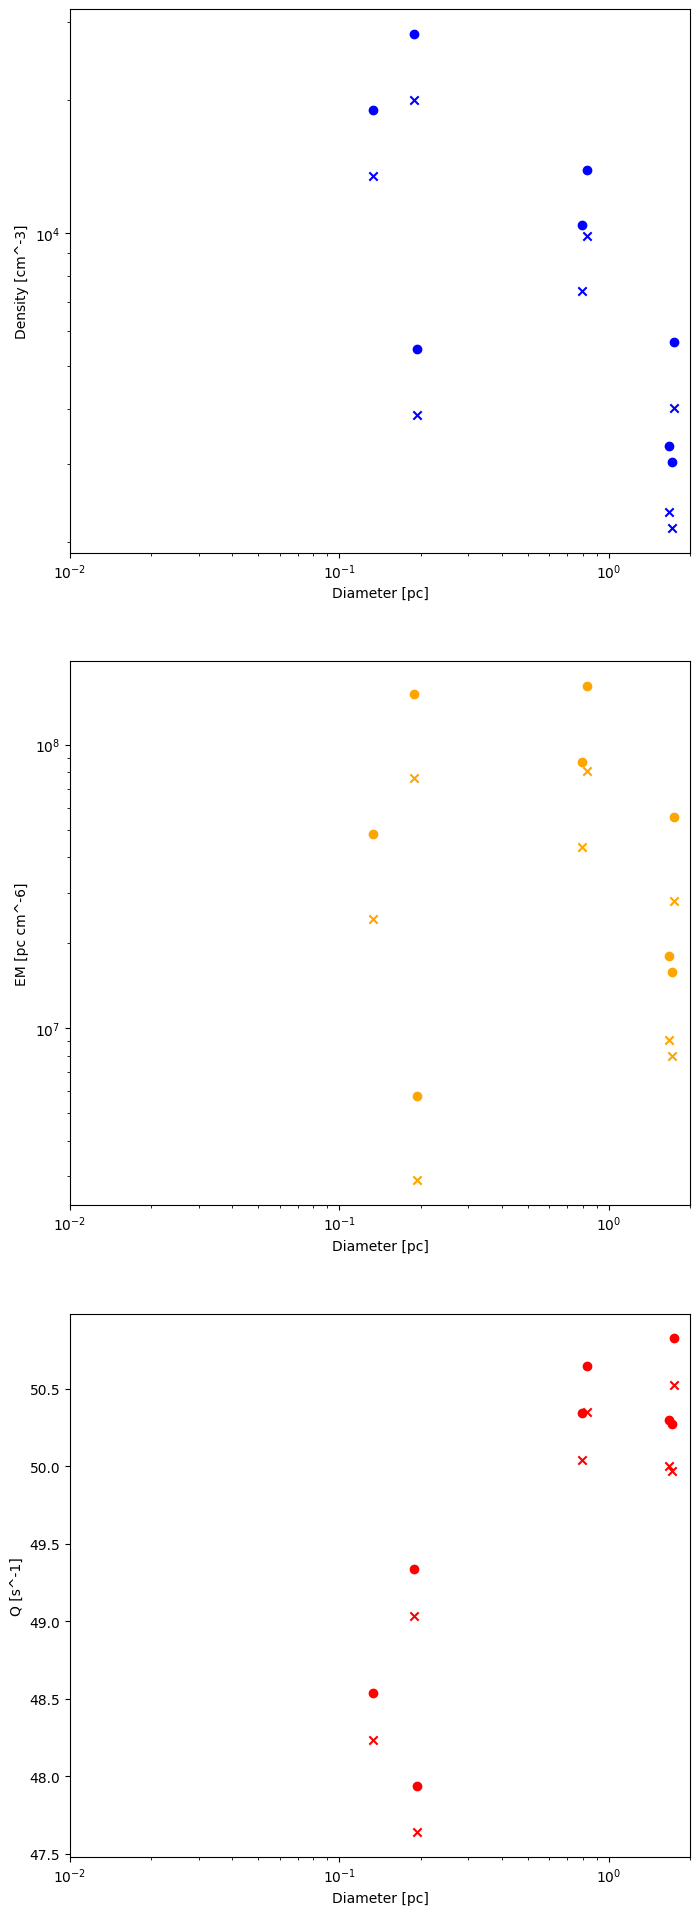

In [ ]:
fig = plt.figure(figsize=(8, 24))
ax1 = fig.add_subplot(311)
ax1.scatter(2*(params['reg_radius_au']*u.au).to(u.pc), params['density_from_bra'], color='blue')
ax1.scatter(2*(params['reg_radius_au']*u.au).to(u.pc), params['density_from_paa'], color='blue',marker='x')
ax1.set_xlabel('Diameter [pc]')
ax1.set_ylabel('Density [cm^-3]')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(1e-2, 2e0)
ax2 = fig.add_subplot(312)
ax2.scatter(2*(params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IBra'], color='orange')
ax2.scatter(2*(params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IPaa'], color='orange',marker='x')
ax2.set_xlabel('Diameter [pc]')
ax2.set_ylabel('EM [pc cm^-6]')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e-2,2e0)
ax3 = fig.add_subplot(313)
ax3.scatter(2*(params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_bra'], color='red')
ax3.scatter(2*(params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_paa'], color='red',marker='x')
ax3.set_xlabel('Diameter [pc]')
ax3.set_ylabel('Q [s^-1]')
ax3.set_xscale('log')
ax3.set_xlim(1e-2,2e0)
#ax3.set_yscale('log')

delta_lam: 236.59542237910327 Angstrom
delta_lam_bra: 454.94571260238206 Angstrom
S_paa: [279.51739929 487.55772531 155.62901551  50.91828288  94.3244763
  18.59555886 179.56068113 518.22547207  58.00775324] MJy / sr
S_bra: [ 197.64670118  419.36996831  423.12200568  213.83319739  652.34526996
  232.8348057   296.05888267 2690.81004482   41.35795409] MJy / sr
reg_radius_au: [np.float64(82215.0), np.float64(19544.760000000002), np.float64(13778.640000000001), np.float64(177538.5), np.float64(240769.26), np.float64(20004.3), np.float64(179238.42), np.float64(85850.82), np.float64(171735.12)]
reg_radius_pc: [np.float64(0.398589567924205), np.float64(0.09475567042002415), np.float64(0.06680073179083097), np.float64(0.8607309372366535), np.float64(1.1672823123861895), np.float64(0.0969835832101949), np.float64(0.8689723819645708), np.float64(0.41621652070472176), np.float64(0.832595357029879)]


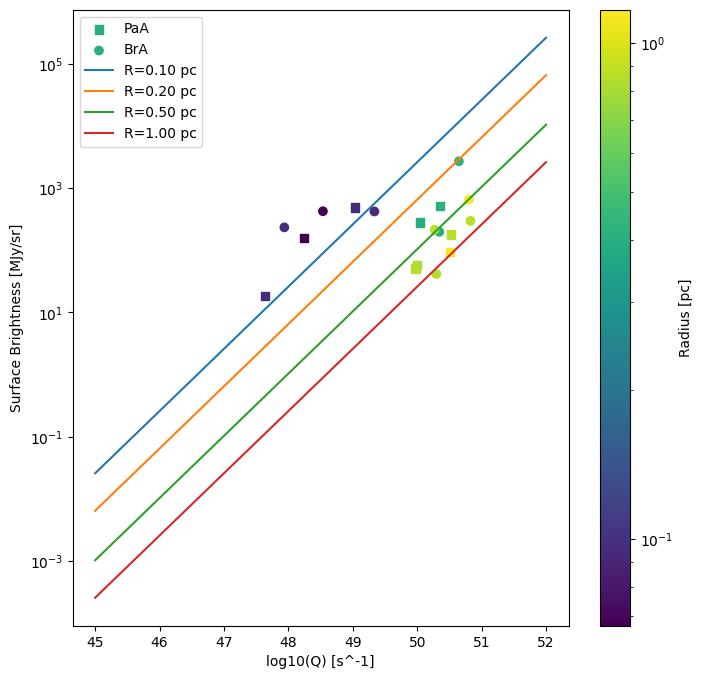

In [ ]:
from matplotlib.colors import LogNorm
# plot Q vs S_paa and S_bra
tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
wave_paa = tab_paa['Wavelength'] 
trans_paa = tab_paa['Transmission']
# get the frequency width of PaA from svo_fps
delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
print('delta_lam:', delta_lam)
delta_nu_paa = (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)


tab_bra = SvoFps.get_transmission_data(f'JWST/NIRCAM.f405n')
wave_bra = tab_bra['Wavelength']
trans_bra = tab_bra['Transmission']
# get the frequency width of BrA from svo_fps
delta_lam_bra = np.trapezoid(trans_bra / trans_bra.max(), wave_bra) * u.AA
print('delta_lam_bra:', delta_lam_bra)
delta_nu_bra = (const.c/4.05e-6/u.m**2 * delta_lam_bra).to(u.Hz)

S_paa = (np.array(params['I_paa']) * u.erg/u.s/u.sr/u.cm**2 / delta_nu_paa).to(u.MJy/u.sr)
S_bra = (np.array(params['I_bra']) * u.erg/u.s/u.sr/u.cm**2 / delta_nu_bra).to(u.MJy/u.sr)
print('S_paa:', S_paa)
print('S_bra:', S_bra)

#color based on their size (reg_radius_au)
print('reg_radius_au:', params['reg_radius_au'])
reg_radius_pc = [(reg_radius_au * u.au).to(u.pc).value for reg_radius_au in params['reg_radius_au']]
print('reg_radius_pc:', reg_radius_pc)

norm = LogNorm(vmin=np.nanmin(reg_radius_pc), vmax=np.nanmax(reg_radius_pc))
cmap = plt.cm.viridis
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)
ax1.scatter(params['Q_from_density_paa'], S_paa, c=reg_radius_pc, cmap=cmap, norm=norm, marker='s', label='PaA')
ax1.scatter(params['Q_from_density_bra'], S_bra, c=reg_radius_pc, cmap=cmap, norm=norm, marker='o', label='BrA')
ax1.set_ylabel('Surface Brightness [MJy/sr]')
ax1.set_xlabel('log10(Q) [s^-1]')
ax1.set_yscale('log')
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax1)
cbar.set_label('Radius [pc]')



def EMfunc(Qlyc=1e45*u.s**-1, R=0.1*u.pc, alpha_b=2e-13*u.cm**3*u.s**-1):
    return (R * (((3 * Qlyc)/(4 * np.pi * R**3 * alpha_b))**0.5)**2).to(u.cm**-6*u.pc)
alpha_b_5e3 = 4.53e-13*u.cm**3*u.s**-1
alpha_b_1e4 = 2.59e-13*u.cm**3*u.s**-1
alpha_b_2e4 = 1.43e-13*u.cm**3*u.s**-1
alpha_b_beta_1e4 = 3.03e-14*u.cm**3*u.s**-1

def alpha_eff(T, line='beta'):
    """ H-alpha recombination coefficient.  eqn 14.8, 14.9 in draine 2001"""
    T4 = (T/(1e4*u.K)).decompose().value
    if line == 'alpha':
        return 1.17e-13 * T4**(-0.942-0.031*np.log(T4)) * u.cm**3*u.s**-1
    elif line == 'beta':
        return 3.03e-14 * T4**(-0.874-0.058*np.log(T4)) * u.cm**3*u.s**-1

hb_to_paa_1e4 = 0.336
alpha_paa = alpha_eff(1e4, line='beta') * hb_to_paa_1e4

from pyspeckit.spectrum.models import hydrogen
wl_paa = hydrogen.wavelength['paschena']*u.um
e_paa = wl_paa.to(u.erg, u.spectral())
nu_paa = wl_paa.to(u.Hz, u.spectral())

wl_hbeta = hydrogen.wavelength['balmerb']*u.um
nu_hbeta = wl_hbeta.to(u.Hz, u.spectral())

wl_halpha = hydrogen.wavelength['balmera']*u.um
nu_halpha = wl_halpha.to(u.Hz, u.spectral())

ha_to_hb_1e4=2.86

def snu_paa(Te=10000*u.K, EM=EMfunc(alpha_b=alpha_b_1e4), angular_area=4*np.pi*u.sr):
    # temperature dependence factor: jhb ~ alpha, so this accounts for the T-dependence of j
    # (which is not explicitly given in Draine)
    alpha_rel = alpha_eff(T=Te, line='beta') / alpha_b_beta_1e4
    jhb_4p = 1.24e-25 * u.erg * u.cm**3 / u.s * hb_to_paa_1e4 * alpha_rel
    flux = EM * jhb_4p
    return (flux/nu_paa).to(u.mJy)/angular_area

Qlyc = np.logspace(45,52,100)*u.s**-1
for radius in (0.1, 0.2, 0.5, 1.0)*u.pc:
    EMs = EMfunc(R=radius, Qlyc=Qlyc)
    snus = snu_paa(Te=1e4*u.K, EM=EMs).to(u.MJy/u.sr)
    ax1.plot(np.log10(Qlyc.value), snus, label=f'R={radius:0.2f}')
ax1.legend()

In [ ]:
# save params to file

import pandas as pd
df = pd.DataFrame(params)
df.to_csv('HII_region_params.csv', index=False)

In [ ]:
# read vla_14GHz_ffpropertiesB.csv

from astropy.table import Table
import numpy as np

ff_tab = Table.read('vla_14GHz_ffpropertiesB.csv', format='csv')
ff_tab
